In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("08-2023.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,38059468304,2023-08-01 09:02,Outbound,00:32:00,NaN,Ray Levesque
1,38059235361,2023-08-01 09:02,NaN,00:00:06,NaN,David Valdez
2,38062413586,2023-08-01 09:45,NaN,00:00:21,NaN,Benjamin Sklivas
3,38062927007,2023-08-01 09:47,NaN,00:00:58,NaN,Tommie Walker
4,38062789761,2023-08-01 09:48,Outbound,00:39:06,NaN,Ray Levesque


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15876 entries, 0 to 15875
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             15876 non-null  int64  
 1   Activity date         15876 non-null  str    
 2   Call direction        831 non-null    str    
 3   Call duration         14928 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  15876 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.3 MB


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 15876 entries, 0 to 15875
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         15876 non-null  datetime64[us]
 1   Call direction        831 non-null    str           
 2   Call duration         14928 non-null  str           
 3   Activity assigned to  15876 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 816.0 KB


# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-08-01 09:02:00,Outbound,00:32:00,Ray Levesque,2023-08-01
1,2023-08-01 09:02:00,NaN,00:00:06,David Valdez,2023-08-01
2,2023-08-01 09:45:00,NaN,00:00:21,Benjamin Sklivas,2023-08-01
3,2023-08-01 09:47:00,NaN,00:00:58,Tommie Walker,2023-08-01
4,2023-08-01 09:48:00,Outbound,00:39:06,Ray Levesque,2023-08-01


In [22]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [24]:
daily_calls.head()

,date,call_count
0,2023-08-01,329
1,2023-08-02,331
2,2023-08-03,413
3,2023-08-04,402
4,2023-08-05,104


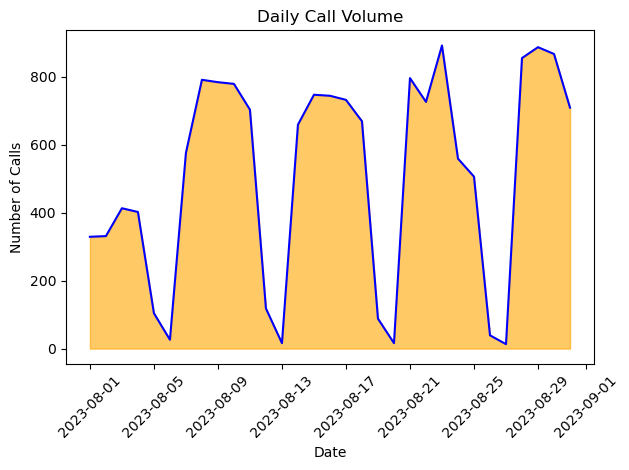

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count Of Call in Weekdays

In [29]:
df1['day'] = df1['Activity date'].dt.day_name()

In [31]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-08-01 09:02:00,Outbound,00:32:00,Ray Levesque,Tuesday
1,2023-08-01 09:02:00,NaN,00:00:06,David Valdez,Tuesday
2,2023-08-01 09:45:00,NaN,00:00:21,Benjamin Sklivas,Tuesday
3,2023-08-01 09:47:00,NaN,00:00:58,Tommie Walker,Tuesday
4,2023-08-01 09:48:00,Outbound,00:39:06,Ray Levesque,Tuesday


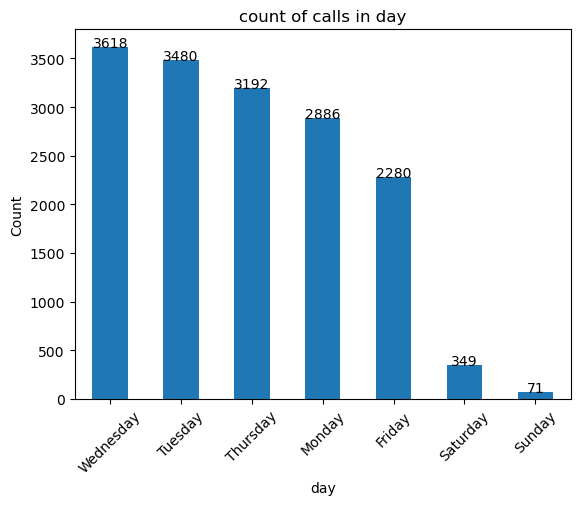

In [33]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

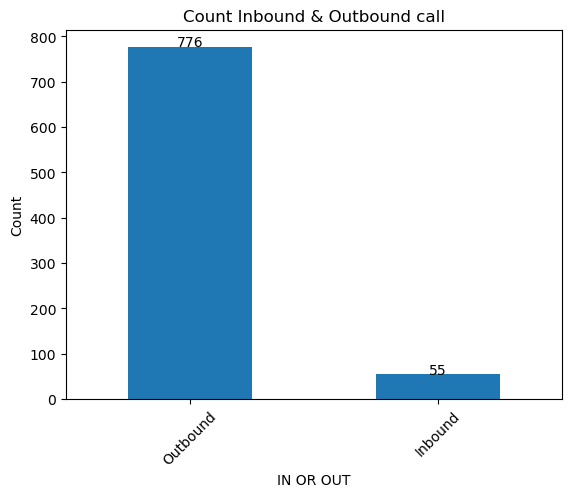

In [36]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [39]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

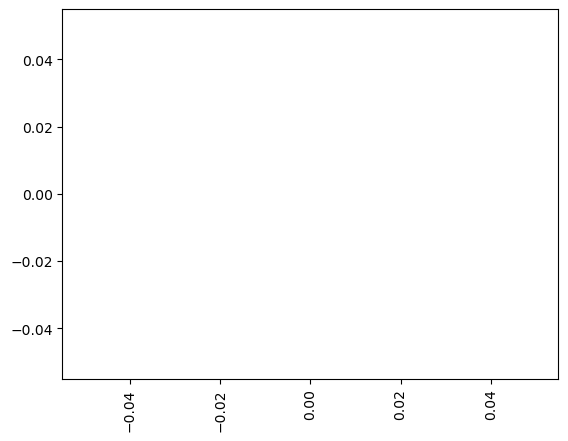

In [41]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [44]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
11,2023-08-01 10:10:00,Outbound,NaN,Robin Stoehr,Tuesday
15,2023-08-01 10:16:00,Outbound,NaN,Robin Stoehr,Tuesday
113,2023-08-01 13:28:00,Outbound,NaN,Jinky Rance,Tuesday
145,2023-08-01 14:30:00,Outbound,NaN,Robin Stoehr,Tuesday
146,2023-08-01 14:30:00,Outbound,NaN,Robin Stoehr,Tuesday
...,...,...,...,...,...
15582,2023-08-31 17:09:00,Outbound,NaN,Jinky Rance,Thursday
15597,2023-08-31 17:18:00,Outbound,NaN,Jinky Rance,Thursday
15598,2023-08-31 17:19:00,Outbound,NaN,Robin Stoehr,Thursday
15620,2023-08-31 18:02:00,Outbound,NaN,Keith Antonio,Thursday


In [46]:
df4 = df1.copy()

In [48]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-08-01 09:02:00,Outbound,00:32:00,Ray Levesque,Tuesday
1,2023-08-01 09:02:00,NaN,00:00:06,David Valdez,Tuesday
2,2023-08-01 09:45:00,NaN,00:00:21,Benjamin Sklivas,Tuesday
3,2023-08-01 09:47:00,NaN,00:00:58,Tommie Walker,Tuesday
4,2023-08-01 09:48:00,Outbound,00:39:06,Ray Levesque,Tuesday


In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

0

In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [56]:
df4 = df4.dropna(subset = ['Call direction'])

In [58]:
(df4['Call duration'] == 0).sum()

249

In [60]:
df4.info()

<class 'pandas.DataFrame'>
Index: 831 entries, 0 to 15681
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         831 non-null    datetime64[us]
 1   Call direction        831 non-null    str           
 2   Call duration         831 non-null    float64       
 3   Activity assigned to  831 non-null    str           
 4   day                   831 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 62.1 KB


# Working Call Assigner

In [63]:
df1['Activity assigned to'].nunique()

22

In [65]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[       'Ray Levesque',        'David Valdez',    'Benjamin Sklivas',
       'Tommie Walker',        'Robin Stoehr',    'Vladimir Suparto',
         'Paol Guzman',         'Sal Berdayi',      'Cameron Dudley',
        'Dioni Canega',        'Karen Parker',         'Adrian Tran',
      'David Banister',       'Keith Antonio',         'Jinky Rance',
        'Louis Maciel',       'Oliver Martin',    'Chrystel Manabat',
          'True Ellis',    'Colby Rintharamy', 'Demmie Rose Tamonan',
           'Terry Kim']
Length: 22, dtype: str

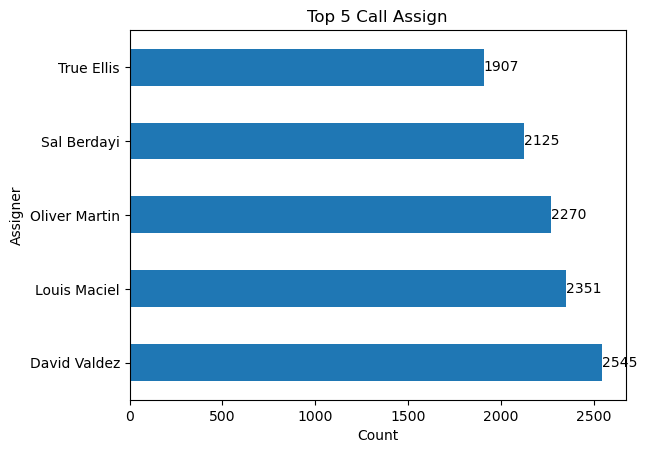

In [67]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [70]:
df4['Call duration'].max()

85.4

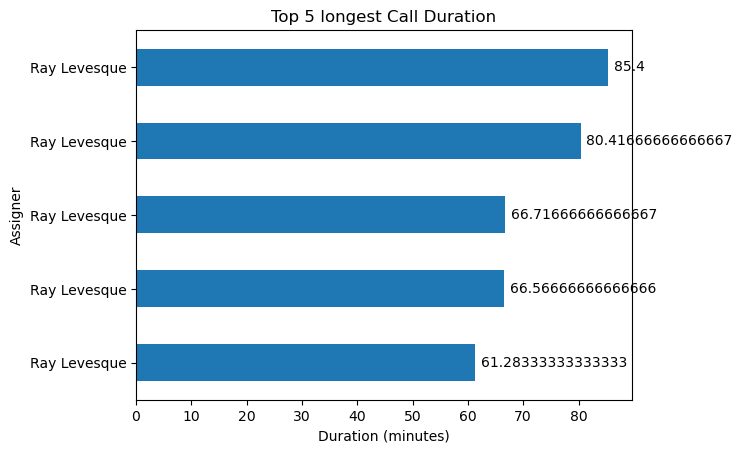

In [72]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [75]:
df3 = df1.copy()

In [77]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [79]:
df3['day'].unique()

<ArrowStringArray>
['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Monday']
Length: 5, dtype: str

In [81]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

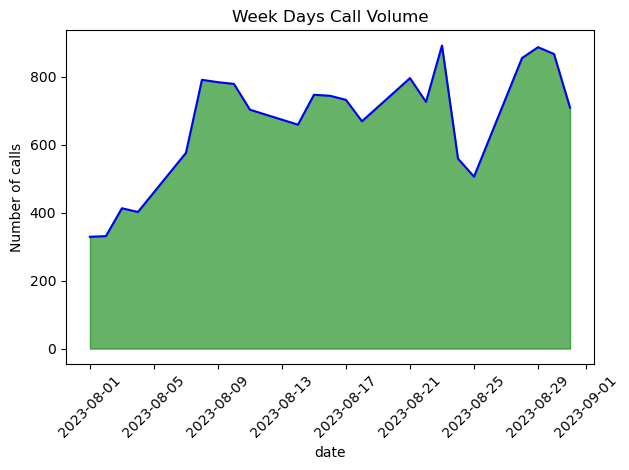

In [83]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [86]:
df5=df4.copy()

In [88]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [90]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
1475,2023-08-05 10:04:00,Outbound,2.183333,Ray Levesque,Saturday
1478,2023-08-05 11:01:00,Outbound,28.183333,Ray Levesque,Saturday
1492,2023-08-05 13:01:00,Outbound,85.400000,Ray Levesque,Saturday
1576,2023-08-05 18:46:00,Outbound,1.833333,Ray Levesque,Saturday
1577,2023-08-05 19:05:00,Outbound,0.750000,Ray Levesque,Saturday


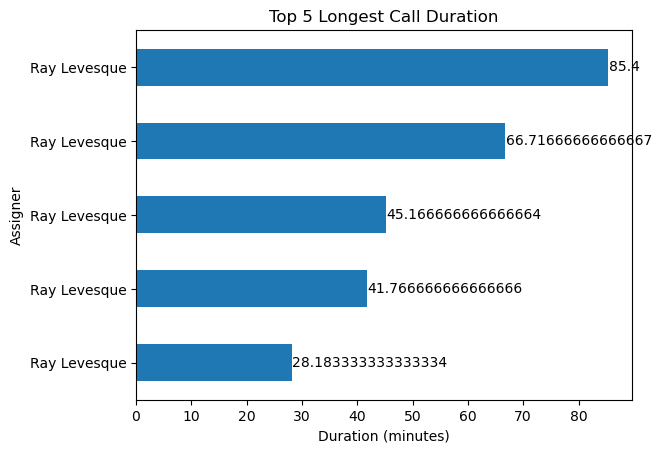

In [92]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

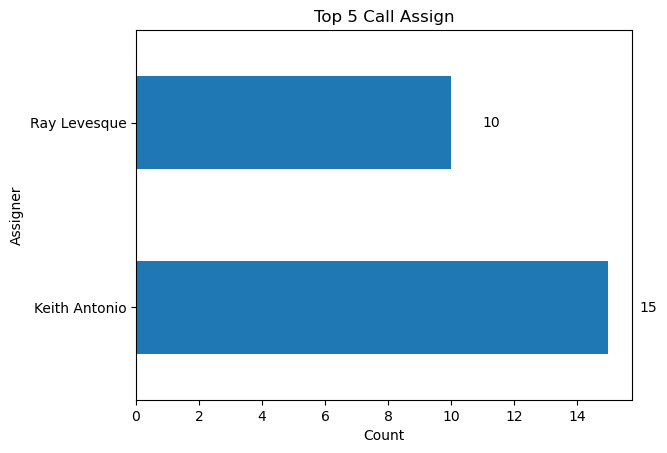

In [95]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Top 5 peak Call date

In [98]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [100]:
top5 = daily_calls.sort_values(ascending=False).head(5)

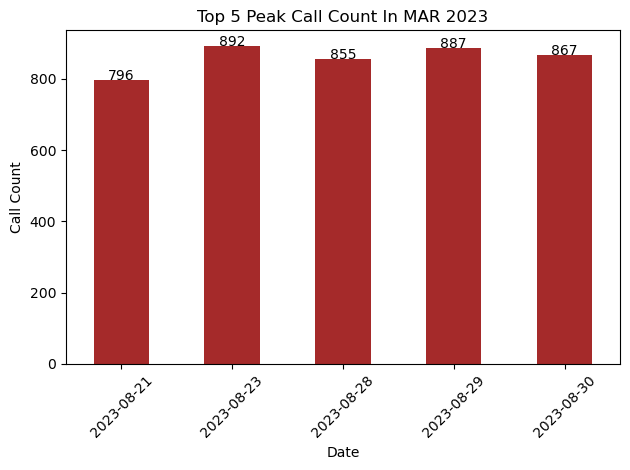

In [102]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In MAR 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()